# Statistical Analysis

## Objective

The purpose of statistical analysis is to validate the insights obtained during exploratory data analysis (EDA). Statistical tests help determine whether observed relationships between variables are statistically significant or occurred by chance.

The key questions answered in this notebook are:

- Does market sentiment affect trader profitability?
- Is there a relationship between market sentiment and profitable trades?
- Do different trading directions produce different average profits?

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

In [3]:
#Load Dataset
df=pd.read_csv("cleaned_bitcoin_data.csv")
df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,timestamp_x,date,timestamp_y,value,classification,profit_flag,hour,day_of_week,is_weekend,sentiment_score
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed,0,22,Monday,0,3.0


In [4]:
#Descriptive Statistics
df.describe()

,execution_price,size_tokens,size_usd,start_position,closed_pnl,order_id,fee,trade_id,timestamp_x,timestamp_y,value,profit_flag,hour,is_weekend,sentiment_score
count,167857.000000,1.678570e+05,1.678570e+05,1.678570e+05,167857.000000,1.678570e+05,167857.000000,1.678570e+05,1.678570e+05,1.678570e+05,167857.000000,167857.00000,167857.000000,167857.000000,167857.000000
mean,10917.135406,5.116982e+03,5.389755e+03,-4.322903e+04,48.853074,6.759207e+10,1.095066,5.623287e+14,1.737162e+12,1.737330e+09,54.698547,0.40970,11.547549,0.225877,2.352330
std,29008.228358,1.133575e+05,3.699618e+04,7.271133e+05,853.621489,1.973031e+10,6.820286,3.257258e+14,9.662754e+09,8.980998e+06,20.253089,0.49178,7.247940,0.418160,1.181169
min,0.000005,2.390000e-06,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.672897e+09,10.000000,0.00000,0.000000,0.000000,0.000000
25%,4.243900,3.000000e+00,1.778500e+02,-6.179100e+02,0.000000,5.654734e+10,0.015122,2.800000e+14,1.730000e+12,1.734586e+09,37.000000,0.00000,5.000000,0.000000,1.000000
50%,19.039000,3.030000e+01,5.632000e+02,5.340682e+01,0.000000,7.328153e+10,0.086361,5.620000e+14,1.740000e+12,1.740116e+09,54.000000,0.00000,12.000000,0.000000,2.000000
75%,30.423000,1.804100e+02,2.014430e+03,8.128972e+03,5.340160,8.233002e+10,0.372278,8.450000e+14,1.740000e+12,1.743399e+09,73.000000,1.00000,19.000000,0.000000,3.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,115287.000000,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746164e+09,94.000000,1.00000,23.000000,1.000000,4.000000


In [5]:
numerical_columns = [
    "execution_price",
    "size_usd",
    "closed_pnl",
    "sentiment_score"
]

for column in numerical_columns:

    print("=" * 50)

    print("Column :", column)

    print("Mean :", df[column].mean())

    print("Median :", df[column].median())

    print("Mode :", df[column].mode()[0])

Column : execution_price
Mean : 10917.135406400135
Median : 19.039
Mode : 2365.6
Column : size_usd
Mean : 5389.754761910436
Median : 563.2
Mode : 554.99
Column : closed_pnl
Mean : 48.85307366496483
Median : 0.0
Mode : 0.0
Column : sentiment_score
Mean : 2.352329661557159
Median : 2.0
Mode : 3.0


In [6]:
for column in numerical_columns:

    print("=" * 50)

    print("Column :", column)

    print("Variance :", df[column].var())

    print("Standard Deviation :", df[column].std())

Column : execution_price
Variance : 841477312.4957547
Standard Deviation : 29008.228358446067
Column : size_usd
Variance : 1368717099.4561307
Standard Deviation : 36996.17682215462
Column : closed_pnl
Variance : 728669.6465040093
Standard Deviation : 853.6214890125536
Column : sentiment_score
Variance : 1.3951593716391797
Standard Deviation : 1.1811686465696505


In [7]:
correlation = df.select_dtypes(include=np.number).corr()

correlation

,execution_price,size_tokens,size_usd,start_position,closed_pnl,order_id,fee,trade_id,timestamp_x,timestamp_y,value,profit_flag,hour,is_weekend,sentiment_score
execution_price,1.000000,-0.016987,0.190989,0.022388,-0.006726,0.131343,0.217833,0.003725,0.145112,0.116652,-0.024496,-0.053756,-0.004211,-0.031686,-0.030664
size_tokens,-0.016987,1.000000,0.013833,0.042982,0.004704,-0.044097,0.007098,-0.003917,-0.041348,-0.042038,0.015321,-0.003264,0.009984,0.002704,0.011559
size_usd,0.190989,0.013833,1.000000,0.009020,0.096929,0.041827,0.744856,-0.000999,0.042505,0.035808,-0.025317,0.003745,-0.002633,-0.000010,-0.025941
start_position,0.022388,0.042982,0.009020,1.000000,0.005426,-0.095169,0.011988,0.000647,-0.115989,-0.082086,-0.051399,0.055532,-0.002233,0.039816,-0.024866
closed_pnl,-0.006726,0.004704,0.096929,0.005426,1.000000,-0.009293,0.066463,0.003071,-0.011534,-0.008816,0.004479,0.100152,-0.002862,0.004109,0.004030
order_id,0.131343,-0.044097,0.041827,-0.095169,-0.009293,1.000000,0.032950,0.003951,0.947599,0.911720,-0.437797,-0.019439,0.005899,-0.076155,-0.427387
fee,0.217833,0.007098,0.744856,0.011988,0.066463,0.032950,1.000000,0.000469,0.038403,0.024262,-0.014270,0.006486,-0.006629,0.001417,-0.014933
trade_id,0.003725,-0.003917,-0.000999,0.000647,0.003071,0.003951,0.000469,1.000000,0.002202,0.004839,-0.006842,-0.003408,0.002136,0.002502,-0.007405
timestamp_x,0.145112,-0.041348,0.042505,-0.115989,-0.011534,0.947599,0.038403,0.002202,1.000000,0.875753,-0.317357,-0.036243,-0.001284,-0.044206,-0.308582
timestamp_y,0.116652,-0.042038,0.035808,-0.082086,-0.008816,0.911720,0.024262,0.004839,0.875753,1.000000,-0.392636,-0.031638,0.006514,-0.069928,-0.386492


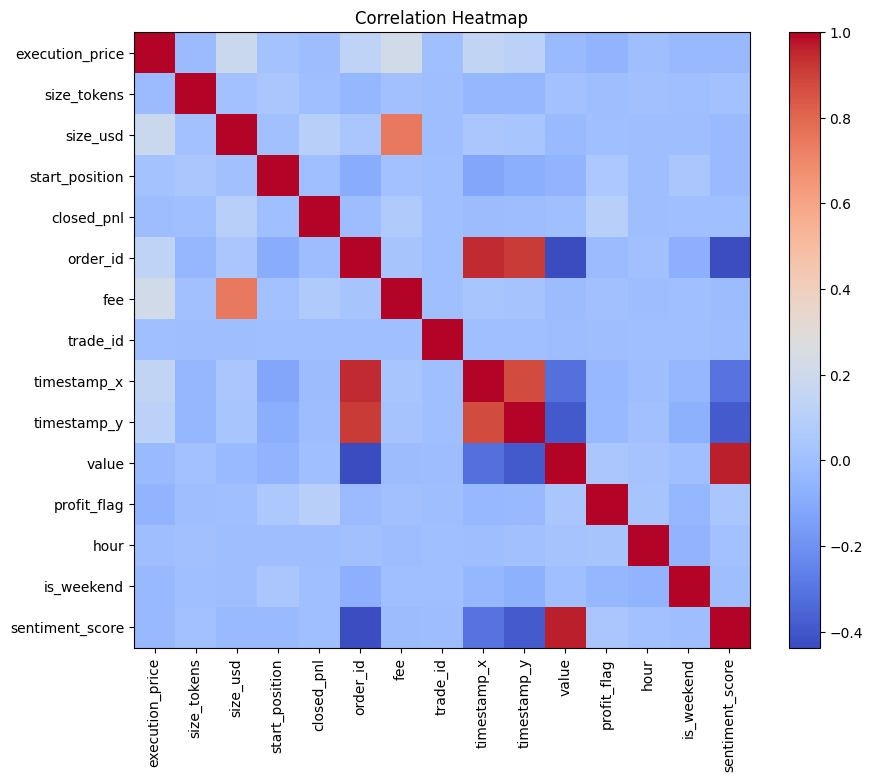

In [8]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
#Independent T-Test
fear = df[df["classification"] == "Fear"]["closed_pnl"]

greed = df[df["classification"] == "Greed"]["closed_pnl"]

t_stat, p_value = ttest_ind(fear, greed)

print("T Statistic :", t_stat)

print("P Value :", p_value)

T Statistic : 3.6449776592532674
P Value : 0.0002675563432070757


In [11]:
#Interpretation
alpha = 0.05

if p_value < alpha:

    print("Reject the Null Hypothesis")

    print("Market sentiment significantly affects trader profitability.")

else:

    print("Fail to Reject the Null Hypothesis")

    print("No significant difference between Fear and Greed.")

Reject the Null Hypothesis
Market sentiment significantly affects trader profitability.


In [12]:
#Chi-Square Test
contingency_table = pd.crosstab(
    df["classification"],
    df["profit_flag"]
)

contingency_table


profit_flag,0,1
classification,,
Extreme Fear,3298,2113
Extreme Greed,18616,15777
Fear,28962,18353
Greed,28946,19546
Neutral,19264,12982


In [13]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square :", chi2)

print("P Value :", p)

Chi-Square : 458.6672169801869
P Value : 5.80813402406083e-98


In [14]:
if p < 0.05:

    print("Reject Null Hypothesis")

    print("Profitability depends on market sentiment.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No relationship detected.")

Reject Null Hypothesis
Profitability depends on market sentiment.


In [15]:
#ANOVA Test
groups = []

for direction in df["direction"].unique():

    groups.append(

        df[df["direction"] == direction]["closed_pnl"]

    )

f_stat, p_value = f_oneway(*groups)

print("F Statistic :", f_stat)

print("P Value :", p_value)


F Statistic : 153.4423360870257
P Value : 2.9e-322


In [16]:
if p_value < 0.05:

    print("Reject Null Hypothesis")

    print("At least one trading direction has a different average profit.")

else:

    print("Fail to Reject Null Hypothesis")

    print("Average profits are similar across trading directions.")

Reject Null Hypothesis
At least one trading direction has a different average profit.


In [17]:
summary = pd.DataFrame({

    "Test":[

        "T-Test",

        "Chi-Square",

        "ANOVA"

    ],

    "Purpose":[

        "Compare Fear vs Greed",

        "Check Sentiment vs Profit",

        "Compare Trading Directions"

    ],

    "Result":[

        "Based on P-value",

        "Based on P-value",

        "Based on P-value"

    ]

})

summary

,Test,Purpose,Result
0,T-Test,Compare Fear vs Greed,Based on P-value
1,Chi-Square,Check Sentiment vs Profit,Based on P-value
2,ANOVA,Compare Trading Directions,Based on P-value


# Statistical Analysis Conclusion

## Key Findings

- Descriptive statistics provided an overview of the numerical features.
- Correlation analysis identified relationships among numerical variables.
- The Independent T-Test evaluated whether average profitability differs between Fear and Greed market conditions.
- The Chi-Square Test examined whether market sentiment is associated with trade profitability.
- ANOVA compared average profitability across different trading directions.

These statistical tests provide evidence to support or reject assumptions before developing machine learning models.